<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Feature_Extraction_vis_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [5]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:05<00:00, 153MB/s]



In [7]:
import os
import shutil
import random
from PIL import Image
import tensorflow as tf

# Paths
SOURCE_DIR = "/content/PetImages"
BASE_DIR = "/content/data"

# Split ratios
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

classes = ["Cat", "Dog"]

# Function to check valid images
def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()  # check corruption
        return True
    except:
        return False

# Create folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)

# Split files
for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)
    all_files = os.listdir(cls_path)

    valid_files = []

    # Validate images properly
    for f in all_files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            full_path = os.path.join(cls_path, f)
            if is_valid_image(full_path):
                valid_files.append(f)

    print(f"{cls}: {len(valid_files)} valid images")

    random.shuffle(valid_files)

    total = len(valid_files)
    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)

    train_files = valid_files[:train_end]
    val_files = valid_files[train_end:val_end]
    test_files = valid_files[val_end:]

    # Copy files
    for f in train_files:
        shutil.copy(os.path.join(cls_path, f),
                    os.path.join(BASE_DIR, "train", cls, f))

    for f in val_files:
        shutil.copy(os.path.join(cls_path, f),
                    os.path.join(BASE_DIR, "val", cls, f))

    for f in test_files:
        shutil.copy(os.path.join(cls_path, f),
                    os.path.join(BASE_DIR, "test", cls, f))

print("Dataset split complete!")

Cat: 12499 valid images


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dog: 12499 valid images
Dataset split complete!


In [8]:
import os

BASE_DIR = "/content/data"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} SET:")
    total = 0

    for cls in ["Cat", "Dog"]:
        path = os.path.join(BASE_DIR, split, cls)
        count = len(os.listdir(path))
        total += count
        print(f"{cls}: {count}")

    print(f"Total: {total}")


TRAIN SET:
Cat: 7499
Dog: 7499
Total: 14998

VAL SET:
Cat: 2500
Dog: 2500
Total: 5000

TEST SET:
Cat: 2500
Dog: 2500
Total: 5000


In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/train",
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/val",
    image_size=(128, 128),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/data/test",
    image_size=(128, 128),
    batch_size=32
)

Found 14998 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [10]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

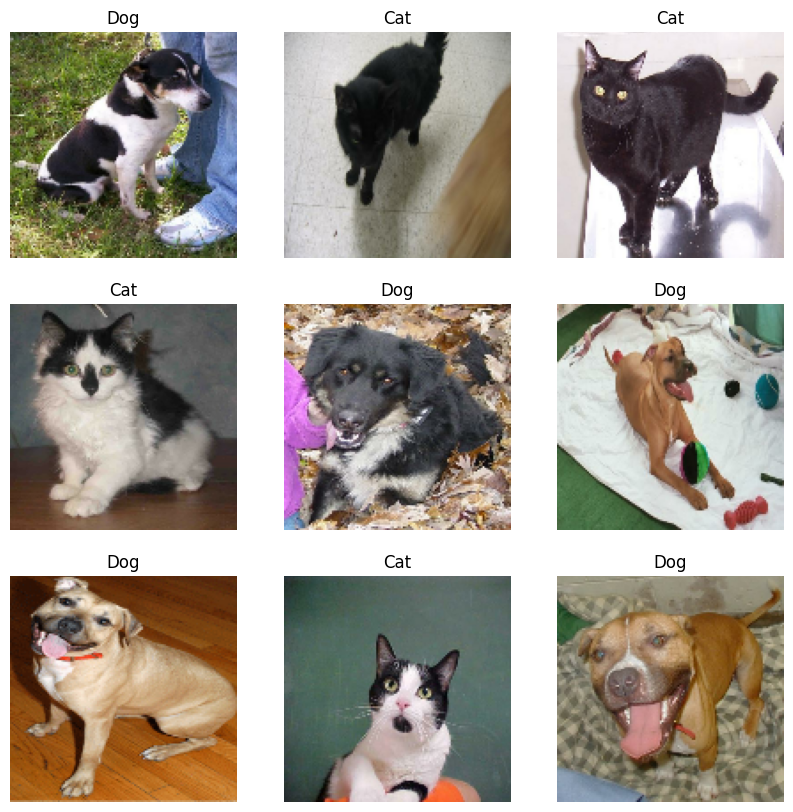

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

class_names = test_ds.class_names # Define class_names here

for images, labels in test_ds.take(12):
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [12]:
## Installing the VGG16

In [13]:
from tensorflow import keras
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
## Extracting the VGG16 features and corresponding labels

In [16]:
import numpy as np
from tensorflow import keras
def get_features_and_labels(datasets):
  all_features = []
  all_labels = []
  for images, labels in datasets:
    preprocessed_images = keras.applications.vgg16.preprocess_input(images)
    features = conv_base.predict(preprocessed_images)
    all_features.append(features)
    all_labels.append(labels)
  return np.concatenate(all_features), np.concatenate(all_labels)

In [17]:
train_features, train_labels = get_features_and_labels(train_ds.ignore_errors())
val_features, val_labels = get_features_and_labels(val_ds.ignore_errors())
test_features, test_labels = get_features_and_labels(test_ds.ignore_errors())

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━

In [18]:
train_features.shape

(14774, 4, 4, 512)

In [23]:
## Now add own dense classifier layer

In [24]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(4, 4, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [25]:
model.compile(
    loss="binary_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)

In [26]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [28]:
history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)

Epoch 1/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9936 - loss: 0.2785 - val_accuracy: 0.9618 - val_loss: 7.0995
Epoch 2/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9929 - loss: 0.4085 - val_accuracy: 0.9572 - val_loss: 7.9593
Epoch 3/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9924 - loss: 0.4014 - val_accuracy: 0.9574 - val_loss: 8.3312
Epoch 4/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9947 - loss: 0.3303 - val_accuracy: 0.9600 - val_loss: 8.2103
Epoch 5/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9942 - loss: 0.2666 - val_accuracy: 0.9582 - val_loss: 9.0473
Epoch 6/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9954 - loss: 0.2464 - val_accuracy: 0.9602 - val_loss: 9.4098
Epoch 7/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9947 - loss: 0.2442 - val_accuracy: 0.9592 - val_loss: 10.1868
Epoch 8/20
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9951 - loss: 0.2972 - val_accuracy: 0

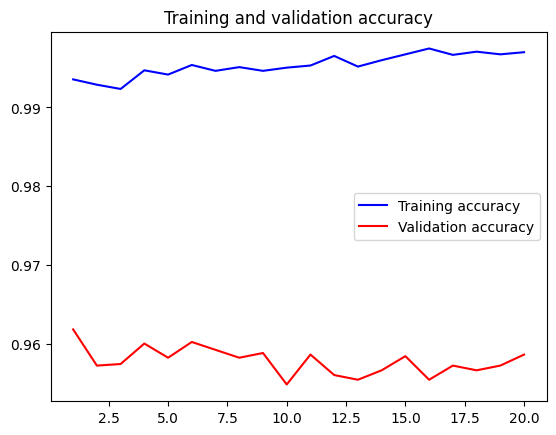

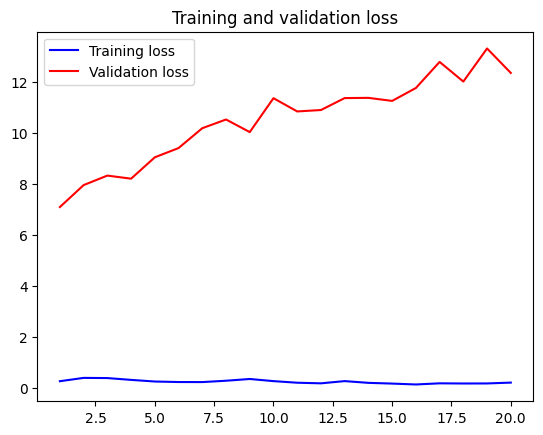

In [29]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy)+1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [30]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9598 - loss: 1.2159
Test accuracy: 0.960


In [31]:
## Freezing the VGG16 base

In [35]:
from tensorflow import keras
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)
conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [36]:
conv_base.trainable = True
print("No of Trainable weigths before freezing: ", len(conv_base.trainable_weights))
conv_base.trainable = False
print("No of Trainable weigths after freezing: ", len(conv_base.trainable_weights))

No of Trainable weigths before freezing:  26
No of Trainable weigths after freezing:  0


In [38]:
## Now augment the dataset

In [39]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

In [40]:
inputs = keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [41]:
model.compile(
    loss="binary_crossentropy",
    optimizer="rmsprop",
    metrics=["accuracy"]
)
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]


In [44]:
history = model.fit(
    train_ds.ignore_errors(),
    epochs=10,
    validation_data=val_ds.ignore_errors(),
    callbacks=callbacks
)

Epoch 1/10
    461/Unknown 24s 51ms/step - accuracy: 0.9207 - loss: 1.2322

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


462/462 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.9166 - loss: 0.9343 - val_accuracy: 0.9420 - val_loss: 0.6987
Epoch 2/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 33s 72ms/step - accuracy: 0.9197 - loss: 0.6335 - val_accuracy: 0.9362 - val_loss: 0.8298
Epoch 3/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9199 - loss: 0.6950 - val_accuracy: 0.9542 - val_loss: 0.6827
Epoch 4/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.9261 - loss: 0.7198 - val_accuracy: 0.9522 - val_loss: 0.6698
Epoch 5/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - accuracy: 0.9309 - loss: 0.7311 - val_accuracy: 0.9558 - val_loss: 0.6859
Epoch 6/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9320 - loss: 0.7509 - val_accuracy: 0.9598 - val_loss: 0.8783
Epoch 7/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9316 - loss: 0.7876 - val_accuracy: 0.9576 - val_loss: 0.7989
Epoch 8/10
462/462 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9324 - loss: 0.7942 - val_accurac

In [45]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_ds.ignore_errors())
print(f"Test accuracy: {test_acc:.3f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9540 - loss: 0.5336
Test accuracy: 0.954


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


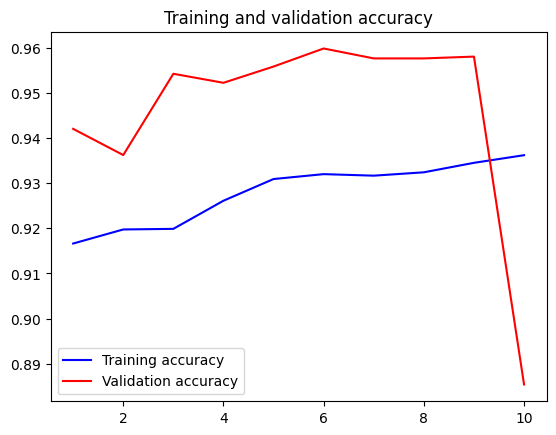

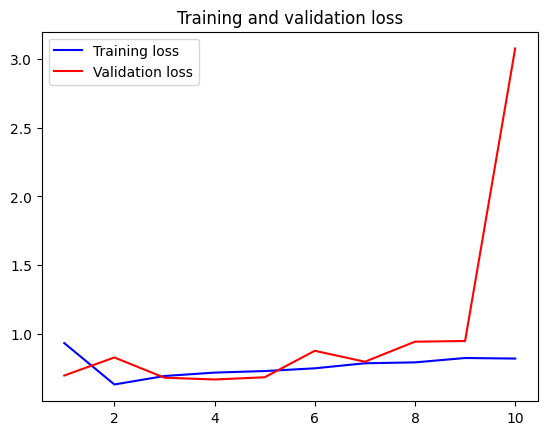

In [46]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy)+1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()